Saved → A_missing_values.png


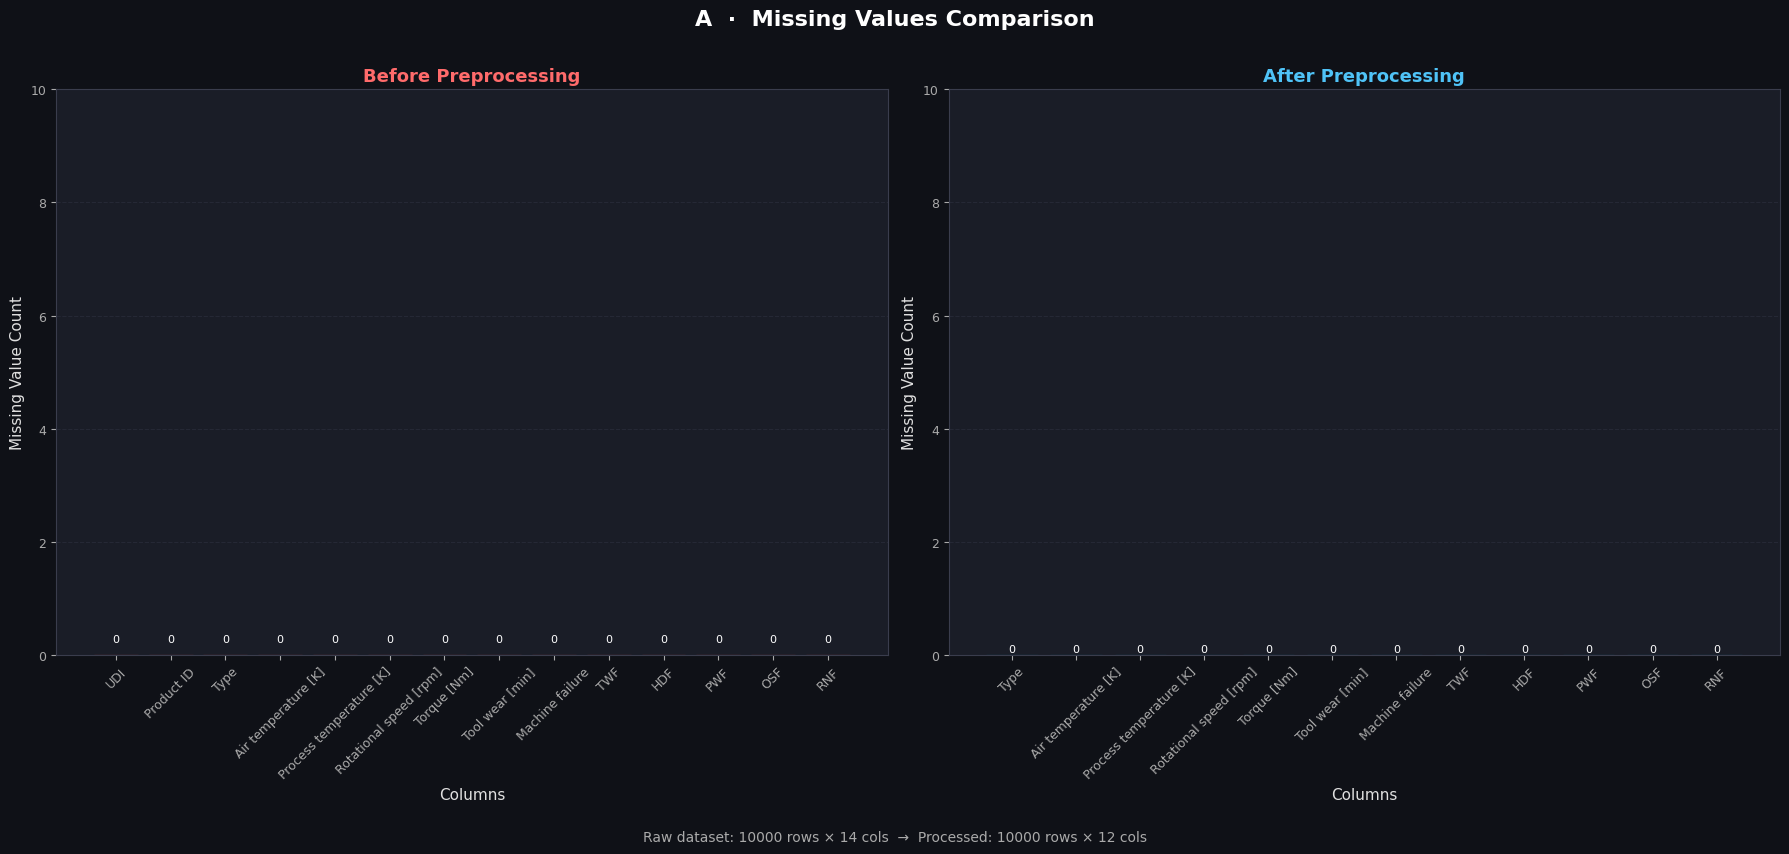

Saved → B_distribution_comparison.png


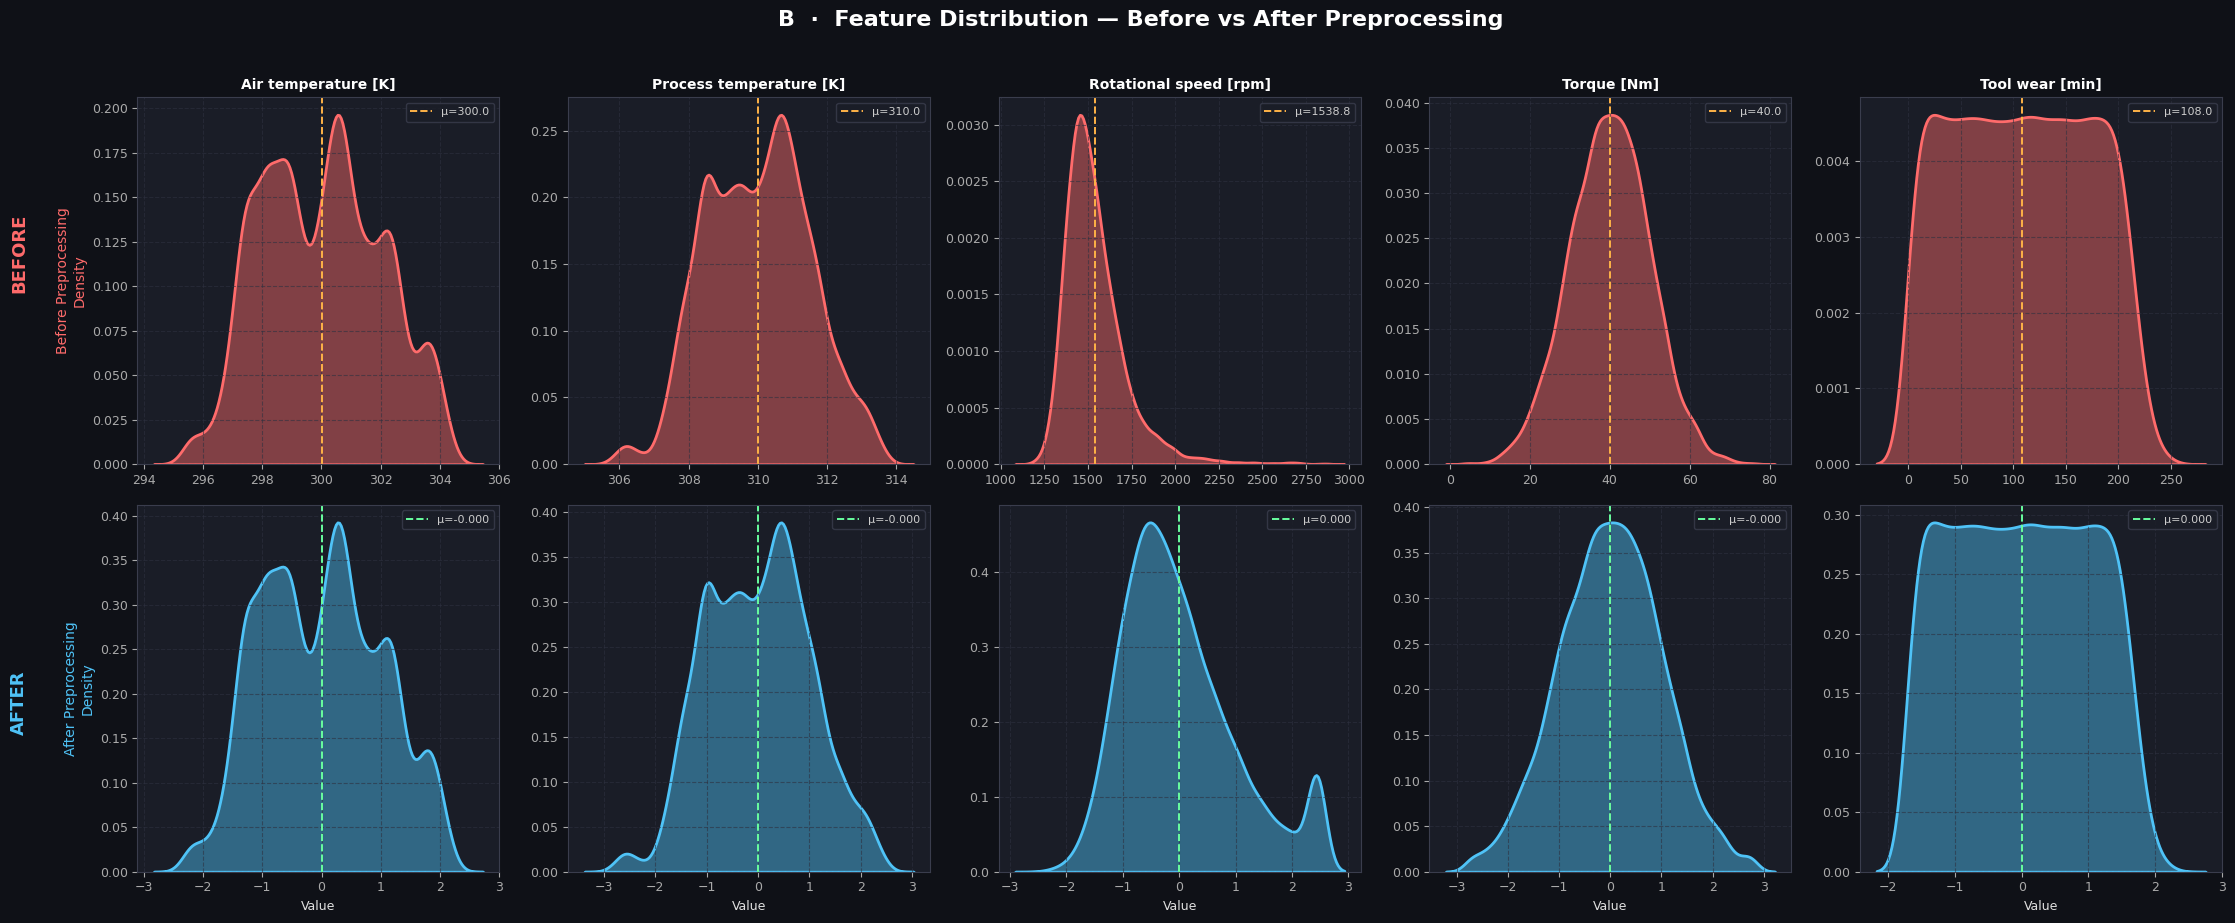

/tmp/ipykernel_2104/3824144931.py:224: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_2104/3824144931.py:224: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


Saved → C_outlier_boxplots.png


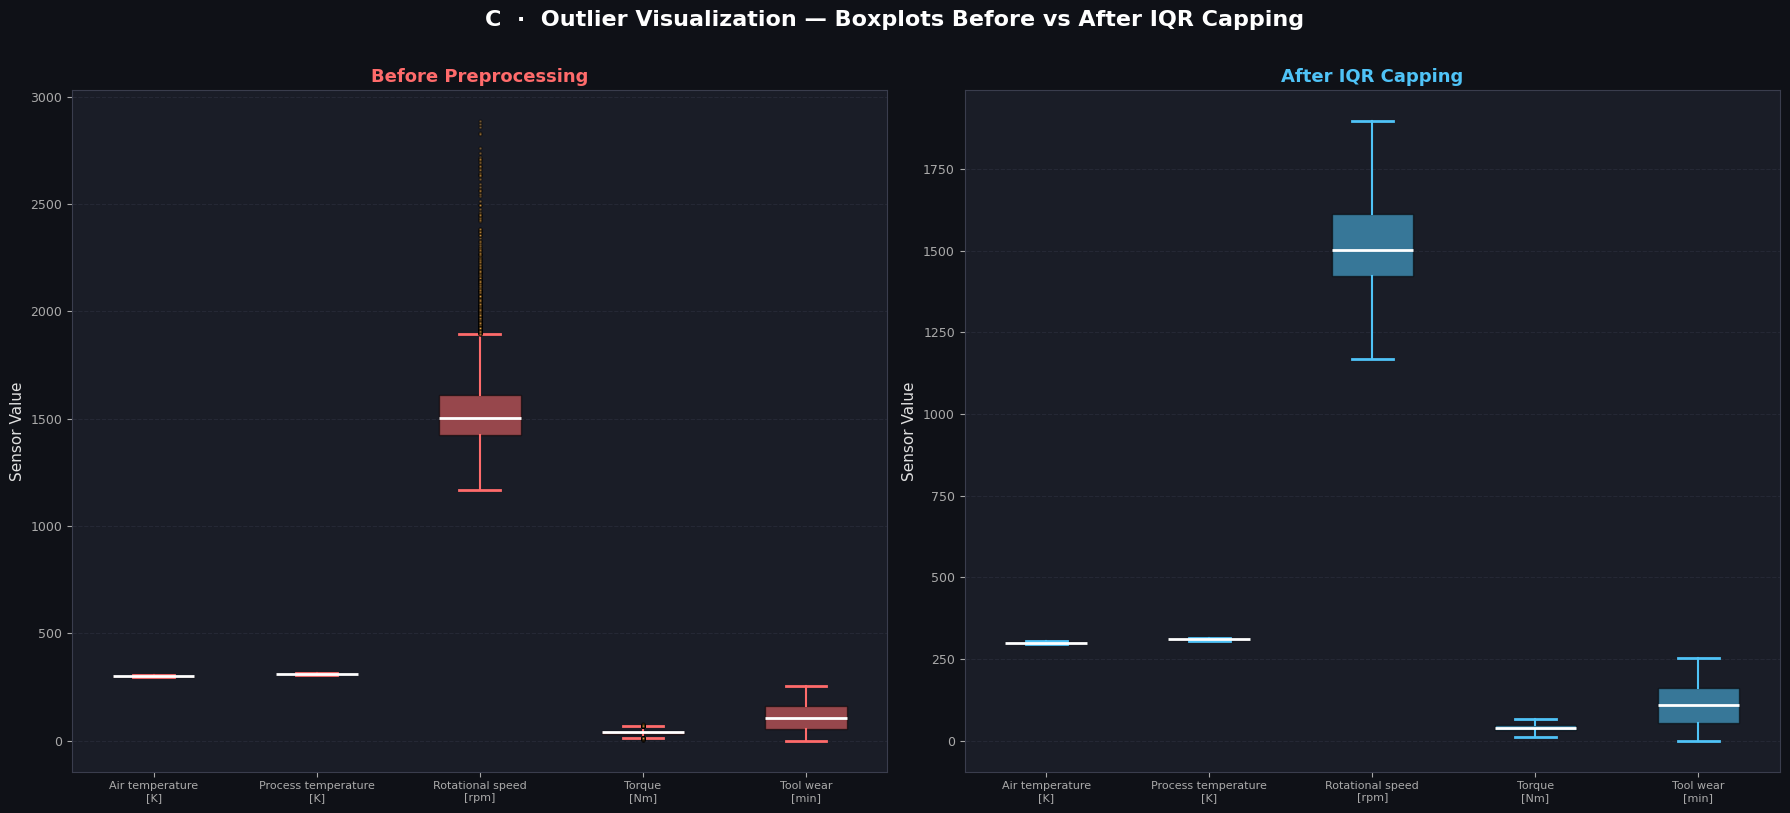

Saved → D_correlation_heatmap.png


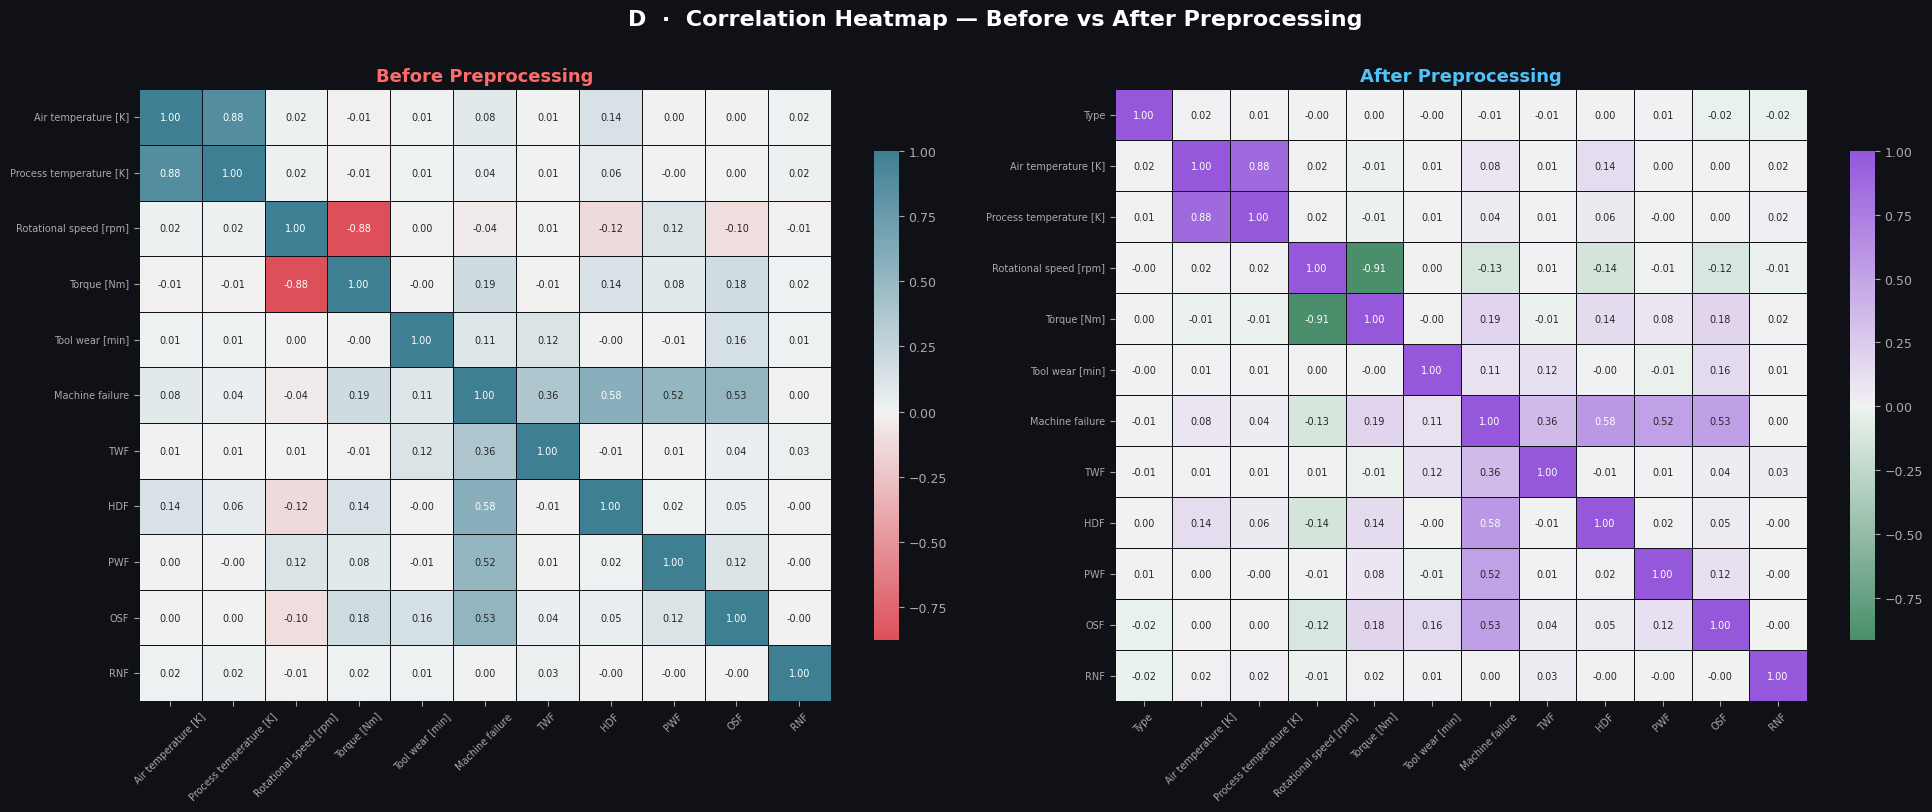

Saved → E_scaling_effect.png


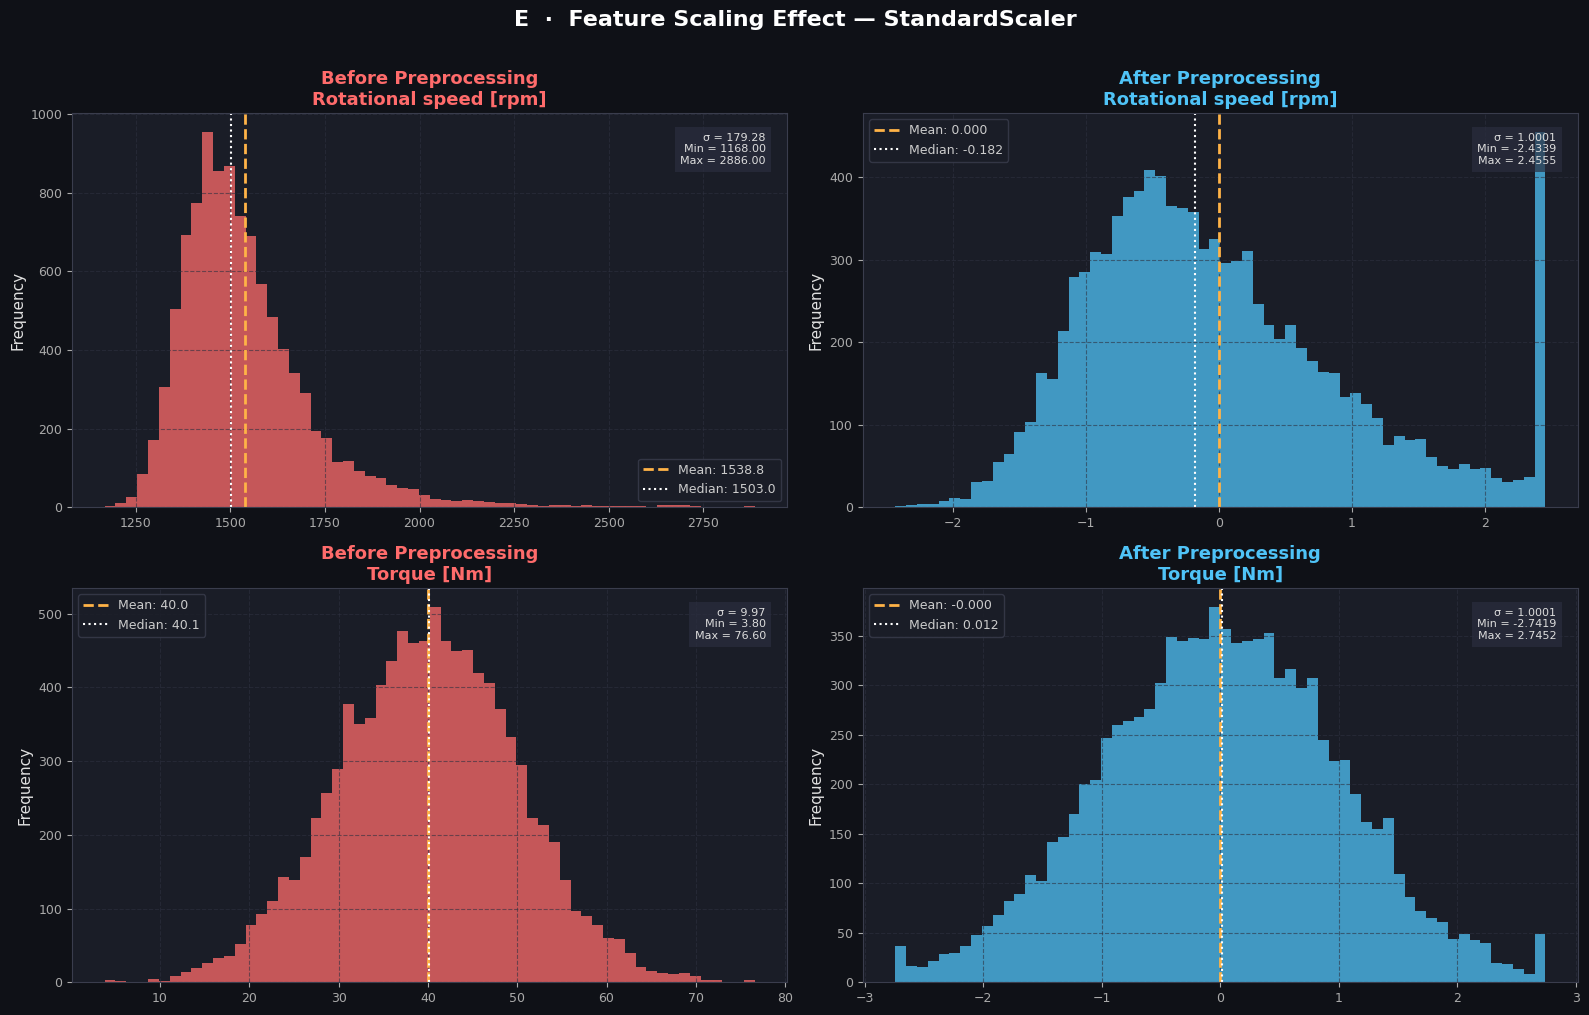

Saved → F_engineered_features.png


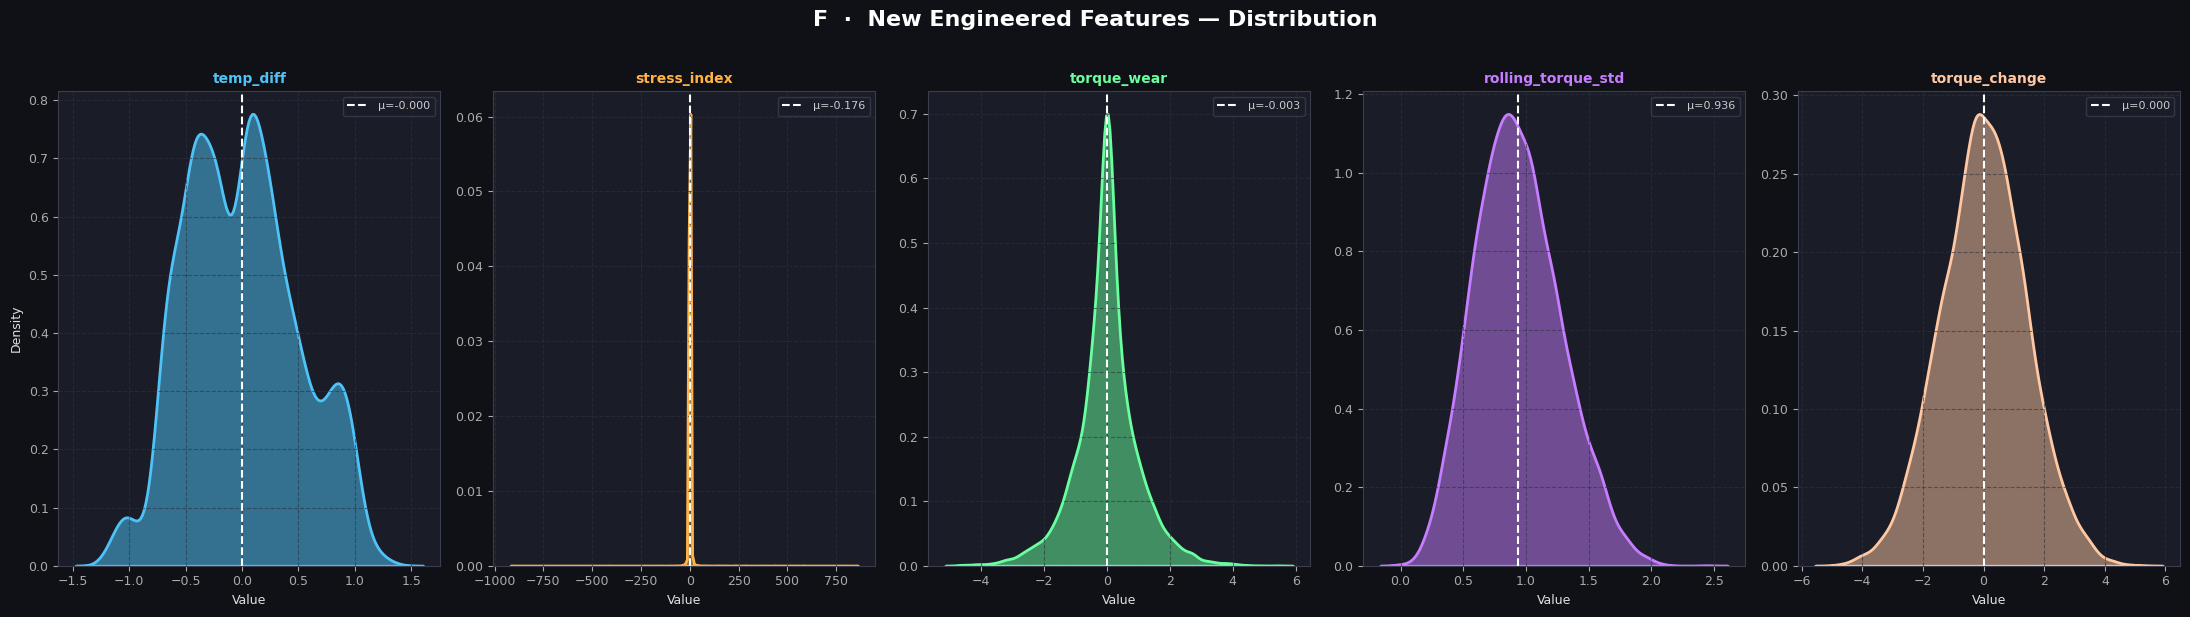


✅  All 6 figures saved successfully.
   A_missing_values.png
   B_distribution_comparison.png
   C_outlier_boxplots.png
   D_correlation_heatmap.png
   E_scaling_effect.png
   F_engineered_features.png


In [2]:
"""
============================================================
  BEFORE vs AFTER PREPROCESSING — Predictive Maintenance
  Dataset : AI4I / Honeywell (honeywell.csv)
  Pipeline : Missing-value drop → IQR Capping → Label
             Encoding → StandardScaler → Feature Engineering
============================================================
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder

# ──────────────────────────────────────────────────────────
# GLOBAL STYLE  (PPT-ready)
# ──────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor":  "#0F1117",
    "axes.facecolor":    "#1A1D27",
    "axes.edgecolor":    "#3A3D4D",
    "axes.labelcolor":   "#E0E0E0",
    "axes.titlesize":    13,
    "axes.titleweight":  "bold",
    "axes.titlecolor":   "#FFFFFF",
    "axes.labelsize":    11,
    "xtick.color":       "#AAAAAA",
    "ytick.color":       "#AAAAAA",
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
    "grid.color":        "#2E3140",
    "grid.linestyle":    "--",
    "grid.alpha":        0.6,
    "legend.facecolor":  "#1A1D27",
    "legend.edgecolor":  "#3A3D4D",
    "legend.labelcolor": "#CCCCCC",
    "legend.fontsize":   9,
    "text.color":        "#E0E0E0",
    "font.family":       "DejaVu Sans",
})

BEFORE_COLOR  = "#FF6B6B"   # warm red  – raw data
AFTER_COLOR   = "#4FC3F7"   # cyan-blue – processed data
ACCENT_ORANGE = "#FFB347"
ACCENT_GREEN  = "#69FF9F"

# ──────────────────────────────────────────────────────────
# LOAD & REPRODUCE PIPELINE
# ──────────────────────────────────────────────────────────

df_raw = pd.read_csv('/content/honeywell.csv')

# Columns used as sensor features throughout the notebook
sensor_cols = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
]

# ── Reproduce preprocessing on a working copy ──
df = df_raw.copy()

# 1. Drop nulls
df = df.dropna()

# 2. IQR capping (outlier removal)
df_iqr_capped = df.copy()          # snapshot after capping, before scaling
for col in sensor_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lb  = Q1 - 1.5 * IQR
    ub  = Q3 + 1.5 * IQR
    df[col]           = np.clip(df[col],           lb, ub)
    df_iqr_capped[col]= np.clip(df_iqr_capped[col], lb, ub)

# 3. Encode categorical
le = LabelEncoder()
df["Type"] = le.fit_transform(df["Type"])

# 4. StandardScaler on sensor columns
scaler = StandardScaler()
df[sensor_cols] = scaler.fit_transform(df[sensor_cols])

# 5. Drop identifiers
df_processed = df.drop(columns=["UDI", "Product ID"])

# ── Feature engineering (done on df post-scaling in notebook) ──
t_air, t_proc = "Air temperature [K]", "Process temperature [K]"
torque, speed, tool_wear = "Torque [Nm]", "Rotational speed [rpm]", "Tool wear [min]"

df["temp_diff"]          = df[t_proc] - df[t_air]
df["stress_index"]       = df[torque] / (df[speed] + 1e-5)
df["torque_wear"]        = df[torque] * df[tool_wear]
df["rolling_torque_std"] = df[torque].rolling(window=5).std().fillna(0)
df["torque_lag1"]        = df[torque].shift(1).fillna(df[torque].median())
df["torque_lag2"]        = df[torque].shift(2).fillna(df[torque].median())
df["speed_lag1"]         = df[speed].shift(1).fillna(df[speed].median())
df["speed_lag2"]         = df[speed].shift(2).fillna(df[speed].median())
df["torque_change"]      = df[torque] - df["torque_lag1"]
df["speed_change"]       = df[speed]  - df["speed_lag1"]

SAVE_DPI = 180
FSIZE    = (18, 8)


# ╔══════════════════════════════════════════════════════════╗
# ║  A. MISSING VALUES COMPARISON                           ║
# ╚══════════════════════════════════════════════════════════╝
fig, axes = plt.subplots(1, 2, figsize=FSIZE)
fig.suptitle("A  ·  Missing Values Comparison", fontsize=16,
             fontweight="bold", color="#FFFFFF", y=1.01)

all_cols_raw  = df_raw.columns.tolist()
missing_before = df_raw[all_cols_raw].isnull().sum()
missing_after  = df_processed.reindex(columns=all_cols_raw, fill_value=0).isnull().sum()

# Before
ax = axes[0]
bars = ax.bar(missing_before.index, missing_before.values, color=BEFORE_COLOR, edgecolor="#FF4444", linewidth=0.8)
ax.set_title("Before Preprocessing", color="#FF6B6B")
ax.set_ylabel("Missing Value Count")
ax.set_xlabel("Columns")
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="y")
for bar, v in zip(bars, missing_before.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
            str(v), ha="center", va="bottom", fontsize=8, color="#FFFFFF")
ax.set_ylim(0, max(missing_before.max() + 5, 10))

# After
ax = axes[1]
proc_cols_present = [c for c in df_processed.columns if c in df_raw.columns]
missing_after_vals = df_processed[proc_cols_present].isnull().sum()
bars = ax.bar(missing_after_vals.index, missing_after_vals.values,
              color=AFTER_COLOR, edgecolor="#0080AA", linewidth=0.8)
ax.set_title("After Preprocessing", color="#4FC3F7")
ax.set_ylabel("Missing Value Count")
ax.set_xlabel("Columns")
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="y")
for bar, v in zip(bars, missing_after_vals.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
            str(v), ha="center", va="bottom", fontsize=8, color="#FFFFFF")
ax.set_ylim(0, max(missing_before.max() + 5, 10))

fig.text(0.5, -0.03,
         f"Raw dataset: {df_raw.shape[0]} rows × {df_raw.shape[1]} cols  "
         f"→  Processed: {df_processed.shape[0]} rows × {df_processed.shape[1]} cols",
         ha="center", fontsize=10, color="#AAAAAA")
plt.tight_layout()
plt.savefig("A_missing_values.png", dpi=SAVE_DPI, bbox_inches="tight",
            facecolor=fig.get_facecolor())
print("Saved → A_missing_values.png")
plt.show()


# ╔══════════════════════════════════════════════════════════╗
# ║  B. FEATURE DISTRIBUTION COMPARISON (KDE)               ║
# ╚══════════════════════════════════════════════════════════╝
features_to_plot = sensor_cols   # 5 features
n_feat = len(features_to_plot)

fig, axes = plt.subplots(2, n_feat, figsize=(22, 9), sharey=False)
fig.suptitle("B  ·  Feature Distribution — Before vs After Preprocessing",
             fontsize=16, fontweight="bold", color="#FFFFFF", y=1.02)

for i, col in enumerate(features_to_plot):
    # --- BEFORE (raw values) ---
    ax_top = axes[0, i]
    sns.kdeplot(df_raw[col], ax=ax_top, color=BEFORE_COLOR, fill=True,
                alpha=0.45, linewidth=2)
    ax_top.set_title(col, fontsize=10, color="#FFFFFF")
    ax_top.set_xlabel("")
    if i == 0:
        ax_top.set_ylabel("Before Preprocessing\nDensity", color=BEFORE_COLOR, fontsize=10)
    else:
        ax_top.set_ylabel("")
    ax_top.grid(True)
    mean_val = df_raw[col].mean()
    ax_top.axvline(mean_val, color=ACCENT_ORANGE, linestyle="--", linewidth=1.4,
                   label=f"μ={mean_val:.1f}")
    ax_top.legend(fontsize=8)

    # --- AFTER (scaled values) ---
    ax_bot = axes[1, i]
    sns.kdeplot(df_processed[col], ax=ax_bot, color=AFTER_COLOR, fill=True,
                alpha=0.45, linewidth=2)
    ax_bot.set_xlabel("Value", fontsize=9)
    if i == 0:
        ax_bot.set_ylabel("After Preprocessing\nDensity", color=AFTER_COLOR, fontsize=10)
    else:
        ax_bot.set_ylabel("")
    ax_bot.grid(True)
    mean_val2 = df_processed[col].mean()
    ax_bot.axvline(mean_val2, color=ACCENT_GREEN, linestyle="--", linewidth=1.4,
                   label=f"μ={mean_val2:.3f}")
    ax_bot.legend(fontsize=8)

# Row labels
for row, label, clr in [(0, "BEFORE", BEFORE_COLOR), (1, "AFTER", AFTER_COLOR)]:
    fig.text(-0.01, 0.75 - row * 0.5, label, ha="center", va="center",
             fontsize=13, fontweight="bold", color=clr, rotation=90)

plt.tight_layout()
plt.savefig("B_distribution_comparison.png", dpi=SAVE_DPI, bbox_inches="tight",
            facecolor=fig.get_facecolor())
print("Saved → B_distribution_comparison.png")
plt.show()


# ╔══════════════════════════════════════════════════════════╗
# ║  C. OUTLIER VISUALIZATION — BOXPLOTS                    ║
# ╚══════════════════════════════════════════════════════════╝
fig, axes = plt.subplots(1, 2, figsize=FSIZE)
fig.suptitle("C  ·  Outlier Visualization — Boxplots Before vs After IQR Capping",
             fontsize=16, fontweight="bold", color="#FFFFFF", y=1.01)

def styled_boxplot(ax, data, cols, color, title):
    bp = ax.boxplot(
        [data[c].dropna().values for c in cols],
        vert=True,
        patch_artist=True,
        labels=[c.replace(" [", "\n[") for c in cols],
        widths=0.5,
        medianprops=dict(color="#FFFFFF", linewidth=2),
        whiskerprops=dict(color=color, linewidth=1.5),
        capprops=dict(color=color, linewidth=2),
        flierprops=dict(marker="o", markerfacecolor=ACCENT_ORANGE,
                        markersize=2, linestyle="none", alpha=0.4),
    )
    for patch in bp["boxes"]:
        patch.set_facecolor(color)
        patch.set_alpha(0.55)
    ax.set_title(title, color=color)
    ax.set_ylabel("Sensor Value")
    ax.grid(axis="y")
    ax.tick_params(axis="x", labelsize=8)

styled_boxplot(axes[0], df_raw,       sensor_cols, BEFORE_COLOR, "Before Preprocessing")
styled_boxplot(axes[1], df_iqr_capped, sensor_cols, AFTER_COLOR,  "After IQR Capping")

plt.tight_layout()
plt.savefig("C_outlier_boxplots.png", dpi=SAVE_DPI, bbox_inches="tight",
            facecolor=fig.get_facecolor())
print("Saved → C_outlier_boxplots.png")
plt.show()


# ╔══════════════════════════════════════════════════════════╗
# ║  D. CORRELATION HEATMAP — BEFORE vs AFTER               ║
# ╚══════════════════════════════════════════════════════════╝
# Use numeric columns only
raw_numeric = df_raw.select_dtypes(include=[np.number])
# Drop identifiers from raw for fair comparison
raw_numeric = raw_numeric.drop(columns=["UDI"], errors="ignore")

proc_numeric = df_processed.select_dtypes(include=[np.number])

corr_before = raw_numeric.corr()
corr_after  = proc_numeric.corr()

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle("D  ·  Correlation Heatmap — Before vs After Preprocessing",
             fontsize=16, fontweight="bold", color="#FFFFFF", y=1.01)

cmap_before = sns.diverging_palette(10, 220, as_cmap=True)   # red-blue
cmap_after  = sns.diverging_palette(145, 280, as_cmap=True)  # teal-purple

sns.heatmap(corr_before, ax=axes[0], annot=True, fmt=".2f",
            cmap=cmap_before, center=0, linewidths=0.4,
            linecolor="#0F1117", annot_kws={"size": 7},
            cbar_kws={"shrink": 0.8})
axes[0].set_title("Before Preprocessing", color=BEFORE_COLOR, fontsize=13)
axes[0].tick_params(axis="x", rotation=45, labelsize=7)
axes[0].tick_params(axis="y", labelsize=7)

sns.heatmap(corr_after, ax=axes[1], annot=True, fmt=".2f",
            cmap=cmap_after, center=0, linewidths=0.4,
            linecolor="#0F1117", annot_kws={"size": 7},
            cbar_kws={"shrink": 0.8})
axes[1].set_title("After Preprocessing", color=AFTER_COLOR, fontsize=13)
axes[1].tick_params(axis="x", rotation=45, labelsize=7)
axes[1].tick_params(axis="y", labelsize=7)

plt.tight_layout()
plt.savefig("D_correlation_heatmap.png", dpi=SAVE_DPI, bbox_inches="tight",
            facecolor=fig.get_facecolor())
print("Saved → D_correlation_heatmap.png")
plt.show()


# ╔══════════════════════════════════════════════════════════╗
# ║  E. FEATURE SCALING EFFECT                              ║
# ╚══════════════════════════════════════════════════════════╝
# Show Rotational speed [rpm] and Torque [Nm] side by side
scale_features = ["Rotational speed [rpm]", "Torque [Nm]"]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("E  ·  Feature Scaling Effect — StandardScaler",
             fontsize=16, fontweight="bold", color="#FFFFFF", y=1.01)

for row, col in enumerate(scale_features):
    raw_vals  = df_raw[col].dropna()
    proc_vals = df_processed[col]

    # --- BEFORE ---
    ax = axes[row, 0]
    ax.hist(raw_vals, bins=60, color=BEFORE_COLOR, alpha=0.75, edgecolor="none")
    ax.axvline(raw_vals.mean(),   color=ACCENT_ORANGE, lw=2, linestyle="--",
               label=f"Mean: {raw_vals.mean():.1f}")
    ax.axvline(raw_vals.median(), color="#FFFFFF",     lw=1.5, linestyle=":",
               label=f"Median: {raw_vals.median():.1f}")
    ax.set_title(f"Before Preprocessing\n{col}", color=BEFORE_COLOR)
    ax.set_ylabel("Frequency")
    ax.legend()
    ax.grid(True)
    stats_text = (f"σ = {raw_vals.std():.2f}\n"
                  f"Min = {raw_vals.min():.2f}\n"
                  f"Max = {raw_vals.max():.2f}")
    ax.text(0.97, 0.95, stats_text, transform=ax.transAxes,
            va="top", ha="right", fontsize=8, color="#DDDDDD",
            bbox=dict(facecolor="#2A2D3E", alpha=0.7, edgecolor="none"))

    # --- AFTER ---
    ax = axes[row, 1]
    ax.hist(proc_vals, bins=60, color=AFTER_COLOR, alpha=0.75, edgecolor="none")
    ax.axvline(proc_vals.mean(),   color=ACCENT_ORANGE, lw=2, linestyle="--",
               label=f"Mean: {proc_vals.mean():.3f}")
    ax.axvline(proc_vals.median(), color="#FFFFFF",     lw=1.5, linestyle=":",
               label=f"Median: {proc_vals.median():.3f}")
    ax.set_title(f"After Preprocessing\n{col}", color=AFTER_COLOR)
    ax.set_ylabel("Frequency")
    ax.legend()
    ax.grid(True)
    stats_text = (f"σ = {proc_vals.std():.4f}\n"
                  f"Min = {proc_vals.min():.4f}\n"
                  f"Max = {proc_vals.max():.4f}")
    ax.text(0.97, 0.95, stats_text, transform=ax.transAxes,
            va="top", ha="right", fontsize=8, color="#DDDDDD",
            bbox=dict(facecolor="#2A2D3E", alpha=0.7, edgecolor="none"))

plt.tight_layout()
plt.savefig("E_scaling_effect.png", dpi=SAVE_DPI, bbox_inches="tight",
            facecolor=fig.get_facecolor())
print("Saved → E_scaling_effect.png")
plt.show()


# ╔══════════════════════════════════════════════════════════╗
# ║  F. BONUS — ENGINEERED FEATURES OVERVIEW               ║
# ╚══════════════════════════════════════════════════════════╝
eng_features = ["temp_diff", "stress_index", "torque_wear",
                "rolling_torque_std", "torque_change"]

fig, axes = plt.subplots(1, len(eng_features), figsize=(22, 6))
fig.suptitle("F  ·  New Engineered Features — Distribution",
             fontsize=16, fontweight="bold", color="#FFFFFF", y=1.02)

colors = [AFTER_COLOR, ACCENT_ORANGE, ACCENT_GREEN, "#C77DFF", "#FFC8A2"]

for i, (col, clr) in enumerate(zip(eng_features, colors)):
    ax = axes[i]
    vals = df[col].dropna()
    sns.kdeplot(vals, ax=ax, color=clr, fill=True, alpha=0.5, linewidth=2)
    ax.axvline(vals.mean(), color="#FFFFFF", lw=1.5, linestyle="--",
               label=f"μ={vals.mean():.3f}")
    ax.set_title(col, color=clr, fontsize=10)
    ax.set_xlabel("Value", fontsize=9)
    ax.set_ylabel("Density" if i == 0 else "", fontsize=9)
    ax.grid(True)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("F_engineered_features.png", dpi=SAVE_DPI, bbox_inches="tight",
            facecolor=fig.get_facecolor())
print("Saved → F_engineered_features.png")
plt.show()

print("\n✅  All 6 figures saved successfully.")
print("   A_missing_values.png")
print("   B_distribution_comparison.png")
print("   C_outlier_boxplots.png")
print("   D_correlation_heatmap.png")
print("   E_scaling_effect.png")
print("   F_engineered_features.png")